# ForeverTree LLM panel — headline figures

Three-panel figure for the H1 comparison (Josh-vs-Mesa pass rates per model),
the gate cascade (where do failing cells get stuck?), and the internal-consistency
violation distributions.

Data source: `analysis/aggregated.csv`, produced by `analysis/aggregate.py`. Re-run
the aggregator any time new batches land:

```
uv run analysis/aggregate.py runs/batch-overnight-YYYYMMDD-i1 runs/batch-overnight-YYYYMMDD-i2 ...
```

All metric definitions come from `SCORING.md`; see the metrics table there for
the canonical field reference.


In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 220,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [2]:
# Panel-scope config. Adjust to your batch.
AGGREGATED = Path('aggregated.csv')
BATCH_FILTER = None              # e.g. ['batch-overnight-20260520-i1', ...] to scope; None = all
MODEL_ORDER  = ['claude', 'gemma', 'kimi', 'minimax', 'mistral']
TARGET_ORDER = ['josh', 'mesa']
TARGET_COLORS = {'josh': '#2b8cbe', 'mesa': '#e34a33'}
OUT_DIR = Path('figures')
OUT_DIR.mkdir(exist_ok=True)


In [3]:
df = pd.read_csv(AGGREGATED)
if BATCH_FILTER is not None:
    df = df[df['batch_tag'].isin(BATCH_FILTER)].copy()
df = df[df['model'].isin(MODEL_ORDER) & df['target'].isin(TARGET_ORDER)].copy()
print(f'rows: {len(df)}')
print(f'batches: {sorted(df.batch_tag.unique())}')
df.groupby(['model', 'target']).size().unstack(fill_value=0).reindex(index=MODEL_ORDER, columns=TARGET_ORDER)


rows: 30
batches: ['batch-overnight-20260520-i1', 'batch-overnight-20260520-i2', 'batch-overnight-20260520-i3']


target,josh,mesa
model,,
claude,3,3
gemma,3,3
kimi,3,3
minimax,3,3
mistral,3,3


In [4]:
def wilson_ci(k: int, n: int, z: float = 1.96) -> tuple[float, float, float]:
    """Return (point, low, high) for a binomial proportion. n=0 -> (nan, 0, 1)."""
    if n == 0:
        return float('nan'), 0.0, 1.0
    phat = k / n
    denom = 1 + z*z/n
    centre = (phat + z*z/(2*n)) / denom
    halfwidth = z * math.sqrt(phat*(1-phat)/n + z*z/(4*n*n)) / denom
    return phat, max(0.0, centre - halfwidth), min(1.0, centre + halfwidth)


def cascade_level(row) -> int:
    """Furthest gate the cell reached. Mutually exclusive levels 0..3:
       0 = no target conformance
       1 = conformed, did not run cleanly
       2 = did_run, but height_year10 or occupancy_year10 out of acceptance range
       3 = did_run AND both spec-parameter gates passed (full pass)
    Each cell occupies exactly one level."""
    if not row.get('target_conformance'):
        return 0
    if not row.get('did_run'):
        return 1
    if not (row.get('height_in_range') and row.get('occupancy_in_range')):
        return 2
    return 3

df['cascade_level'] = df.apply(cascade_level, axis=1)
df[['model','target','target_conformance','did_run','height_in_range','occupancy_in_range','cascade_level']].head()


,model,target,target_conformance,did_run,height_in_range,occupancy_in_range,cascade_level
0,claude,josh,True,True,True,True,3
1,claude,mesa,True,True,True,True,3
2,gemma,josh,False,False,False,False,0
3,gemma,mesa,True,True,True,True,3
4,kimi,josh,True,True,True,True,3


## Panel A — H1: pass rate (`did_run`) by model × target

H1 (EXPERIMENTAL_DESIGN.md): _a higher fraction of Josh implementations will run
and pass validation than Mesa implementations_. Bars show the per-(model, target)
mean of `did_run`; error bars are Wilson 95 % intervals. Labels above bars show `k/N`.


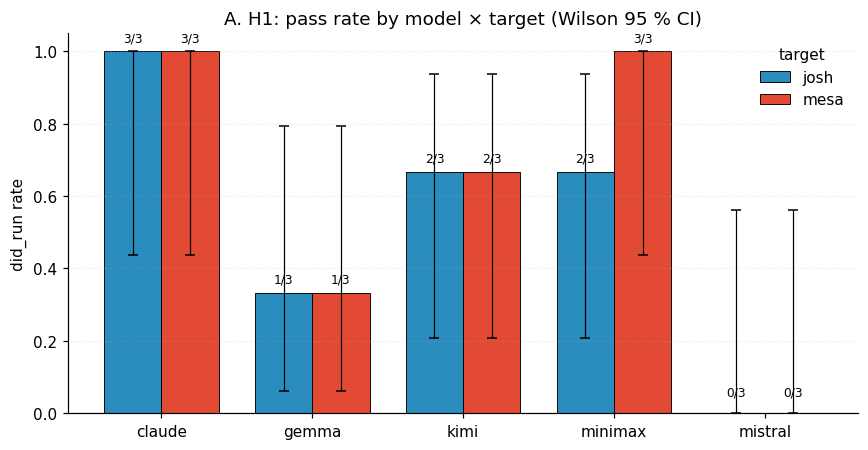

In [5]:
def panel_a(df_in: pd.DataFrame, ax: plt.Axes) -> None:
    width = 0.38
    x = np.arange(len(MODEL_ORDER))
    for i, tgt in enumerate(TARGET_ORDER):
        means, lows, highs, labels = [], [], [], []
        for m in MODEL_ORDER:
            sub = df_in[(df_in.model == m) & (df_in.target == tgt)]
            k = int(sub['did_run'].sum()) if not sub.empty else 0
            n = len(sub)
            phat, lo, hi = wilson_ci(k, n)
            means.append(phat if not math.isnan(phat) else 0)
            lows.append(0 if math.isnan(phat) else phat - lo)
            highs.append(0 if math.isnan(phat) else hi - phat)
            labels.append(f'{k}/{n}' if n else '0/0')
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, means, width, label=tgt, color=TARGET_COLORS[tgt],
                      edgecolor='black', linewidth=0.6)
        ax.errorbar(x + offset, means, yerr=[lows, highs], fmt='none',
                    color='black', capsize=3, linewidth=0.8)
        for xi, lbl, m in zip(x + offset, labels, means):
            ax.text(xi, max(m + 0.02, 0.04), lbl, ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER)
    ax.set_ylabel('did_run rate')
    ax.set_ylim(0, 1.05)
    ax.set_title('A. H1: pass rate by model × target (Wilson 95 % CI)')
    ax.legend(title='target', loc='upper right', frameon=False)
    ax.grid(axis='y', alpha=0.3, linestyle=':')


fig, ax = plt.subplots(figsize=(8, 4.2))
panel_a(df, ax)
fig.tight_layout()
plt.show()


## Panel B — Gate cascade: where do cells get stuck?

Each (model, target) cell-group is a stacked bar across four mutually-exclusive
levels:

| Level | Meaning |
|---|---|
| 0 | `target_conformance = False` — agent didn't use the named framework |
| 1 | conformance ✓, `did_run = False` — script crashed or schema wrong |
| 2 | `did_run` ✓, height_year10 or occupancy_year10 out of acceptance range |
| 3 | full pass — `did_run` ✓ and both spec-parameter gates ✓ |

Caveat from SCORING.md Open Q #1: the acceptance ranges are permissive and
can pass scientifically-broken runs, so level 3 is necessary but not sufficient
for spec faithfulness. Cross-reference Panel C for the internal-consistency view.


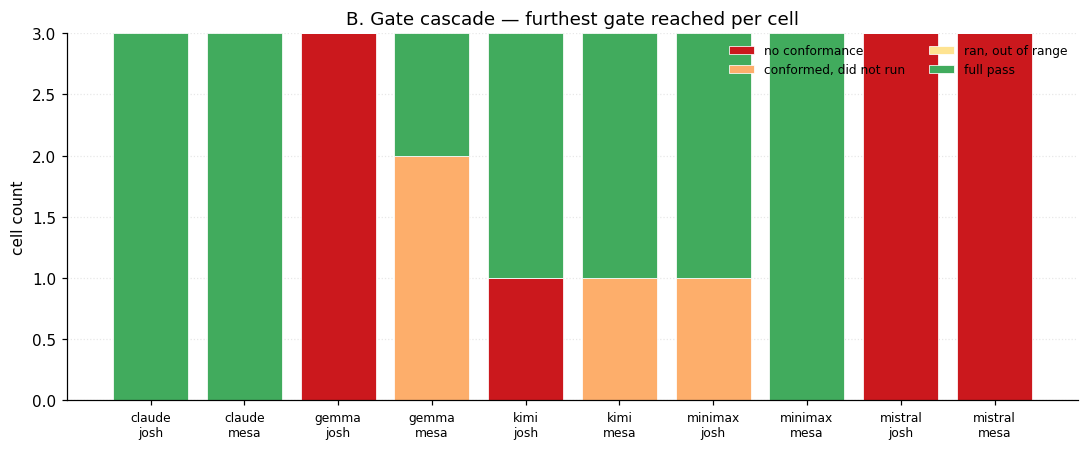

In [6]:
LEVEL_LABELS = {
    0: 'no conformance',
    1: 'conformed, did not run',
    2: 'ran, out of range',
    3: 'full pass',
}
LEVEL_COLORS = {0: '#cb181d', 1: '#fdae6b', 2: '#fee391', 3: '#41ab5d'}


def panel_b(df_in: pd.DataFrame, ax: plt.Axes) -> None:
    groups = [(m, t) for m in MODEL_ORDER for t in TARGET_ORDER]
    counts = {g: {lv: 0 for lv in (0, 1, 2, 3)} for g in groups}
    for g, sub in df_in.groupby(['model', 'target']):
        if g not in counts:
            continue
        for lv, n in sub['cascade_level'].value_counts().items():
            counts[g][int(lv)] = int(n)
    labels = [f'{m}\n{t}' for (m, t) in groups]
    bottoms = np.zeros(len(groups))
    for lv in (0, 1, 2, 3):
        ys = np.array([counts[g][lv] for g in groups])
        ax.bar(labels, ys, bottom=bottoms, color=LEVEL_COLORS[lv],
               edgecolor='white', linewidth=0.5, label=LEVEL_LABELS[lv])
        bottoms += ys
    ax.set_ylabel('cell count')
    ax.set_title('B. Gate cascade — furthest gate reached per cell')
    ax.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0), frameon=False,
              ncols=2, fontsize=8)
    ax.set_axisbelow(True)
    ax.grid(axis='y', alpha=0.3, linestyle=':')
    ax.tick_params(axis='x', labelsize=8)


fig, ax = plt.subplots(figsize=(10, 4.2))
panel_b(df, ax)
fig.tight_layout()
plt.show()


## Panel C — Internal consistency violations

Four spec-implied invariants from SCORING.md §Internal consistency. Each should
be 0 under any faithful implementation; non-zero values are direct spec
violations the other gates can't see. Each point is one cell that produced a
valid CSV (`did_run = True`); cells that didn't run are excluded since the
fractions are undefined.


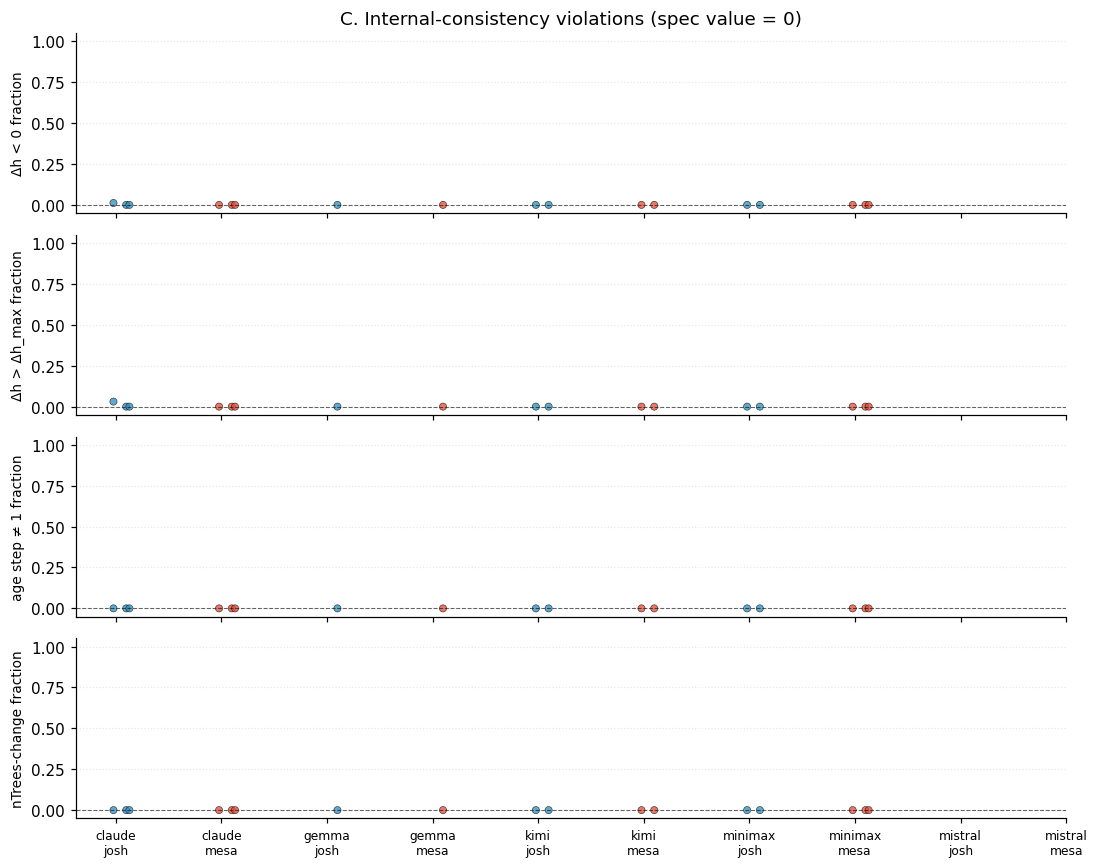

In [7]:
CONSISTENCY_FIELDS = [
    ('growth_rate_negative_frac',       'Δh < 0 fraction'),
    ('growth_rate_above_ceiling_frac',  'Δh > Δh_max fraction'),
    ('age_step_off_one_frac',           'age step ≠ 1 fraction'),
    ('ntrees_change_frac',              'nTrees-change fraction'),
]


def panel_c(df_in: pd.DataFrame, axes: np.ndarray) -> None:
    df_run = df_in[df_in['did_run'] == True].copy()  # noqa: E712 — pandas bool
    df_run['xkey'] = df_run['model'] + '\n' + df_run['target']
    groups = [f'{m}\n{t}' for m in MODEL_ORDER for t in TARGET_ORDER]
    x_index = {g: i for i, g in enumerate(groups)}
    for ax, (field, label) in zip(axes, CONSISTENCY_FIELDS):
        xs, ys, cs = [], [], []
        for g in groups:
            sub = df_run[df_run['xkey'] == g]
            if sub.empty:
                continue
            # Jitter for visibility when multiple cells coincide.
            jitter = np.random.default_rng(seed=42).uniform(-0.18, 0.18, size=len(sub))
            tgt = sub['target'].iloc[0] if not sub.empty else 'josh'
            xs.extend(x_index[g] + jitter)
            ys.extend(sub[field].astype(float))
            cs.extend([TARGET_COLORS[t] for t in sub['target']])
        ax.scatter(xs, ys, c=cs, s=22, alpha=0.75, edgecolor='black', linewidth=0.4)
        ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.6)
        ax.set_xticks(range(len(groups)))
        ax.set_xticklabels(groups, fontsize=7)
        ax.set_ylabel(label, fontsize=9)
        ax.set_ylim(-0.05, max(1.05, (max(ys) if ys else 0) + 0.05))
        ax.grid(axis='y', alpha=0.3, linestyle=':')
    axes[0].set_title('C. Internal-consistency violations (spec value = 0)')


fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
panel_c(df, axes)
axes[-1].tick_params(axis='x', labelsize=8)
fig.tight_layout()
plt.show()


## Combined headline figure (export)

Stack all three panels into one figure and save to `figures/headline.{pdf,png}`.


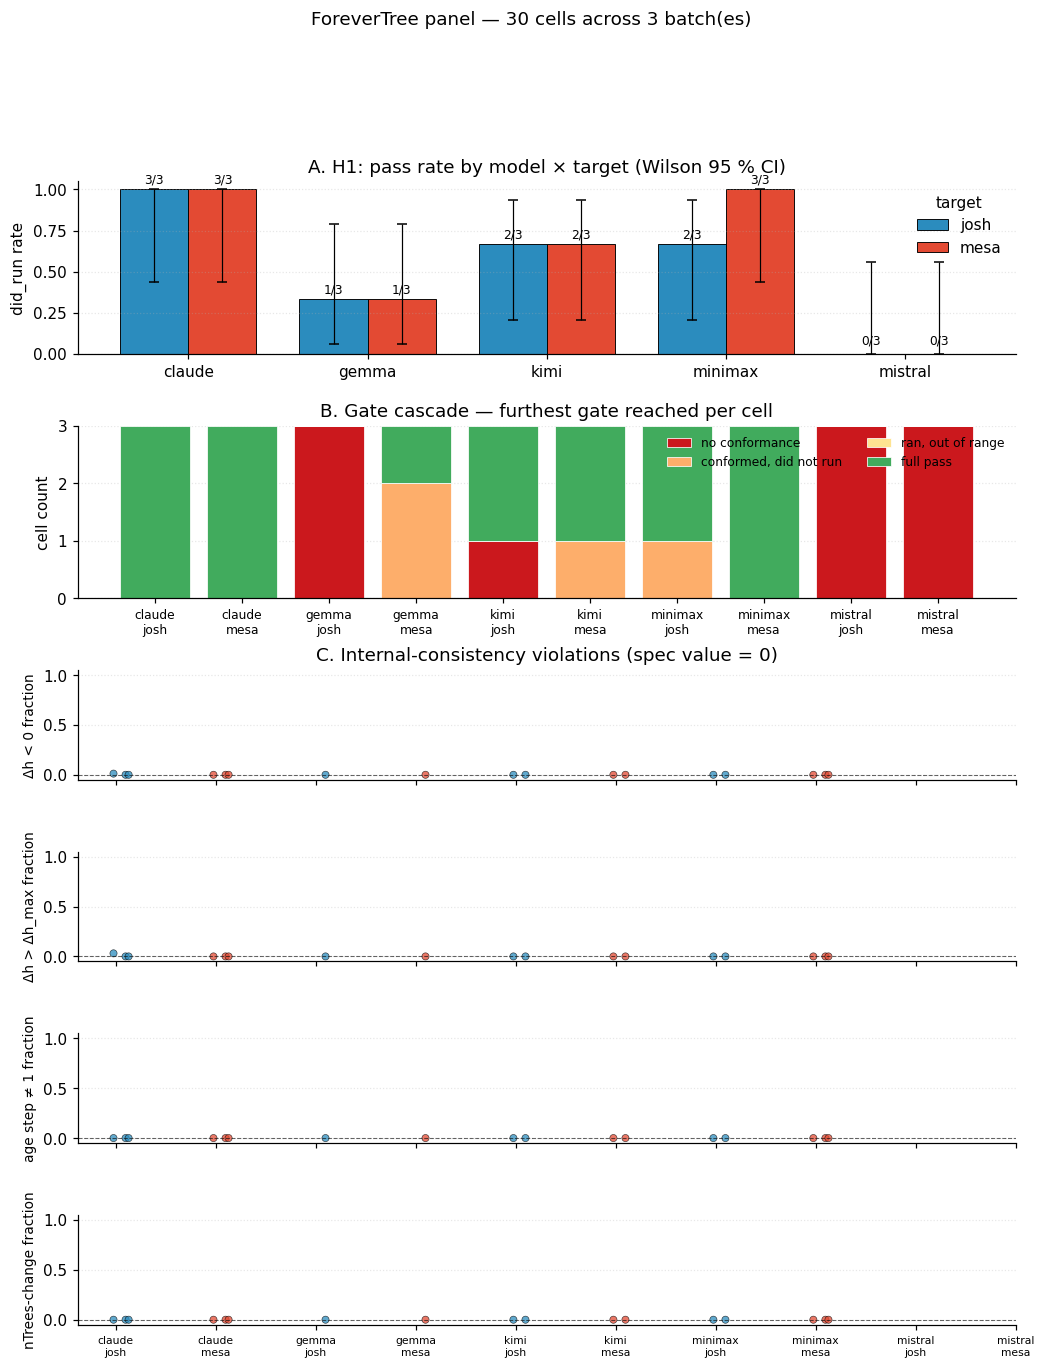

Wrote figures/headline.pdf and figures/headline.png


In [9]:
fig = plt.figure(figsize=(11, 13.5))
gs = fig.add_gridspec(6, 1, height_ratios=[2.2, 2.2, 1.4, 1.4, 1.4, 1.4], hspace=0.55)
ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])
axes_c = np.array([fig.add_subplot(gs[2 + i]) for i in range(4)])
for ax in axes_c[:-1]:
    ax.tick_params(labelbottom=False)
panel_a(df, ax_a)
panel_b(df, ax_b)
panel_c(df, axes_c)
fig.suptitle(
    f'ForeverTree panel — {len(df)} cells across '
    f'{df.batch_tag.nunique()} batch(es)',
    fontsize=12, y=0.995,
)
fig.savefig(OUT_DIR / 'headline.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'headline.png', bbox_inches='tight')
plt.show()
print(f'Wrote {OUT_DIR / "headline.pdf"} and {OUT_DIR / "headline.png"}')


## Ecology panel — observed year-10 means vs spec values

The ecological content of [prompts/BASE_PROMPT.md](../prompts/BASE_PROMPT.md)
pins three quantities we can compare against directly:

| Quantity | Spec value | Source |
|---|---|---|
| `Δh_max` (peak growth) | 1 m / yr | BASE_PROMPT §Growth Model |
| Stochastic offset `O` | `N(1, 0.05)` → 3σ ceiling 1.15 | BASE_PROMPT §Stochasticity |
| `nTrees` per patch | exactly 10, constant for all 11 steps | BASE_PROMPT §Entities (no death / reproduction / migration) |
| `meanHeight` @ year 10 — peak | ~10 m at the centre of the synthetic gradient | EXPERIMENTAL_DESIGN §External climate inputs |
| `meanHeight` @ year 10 — across-cell mean | ~4.5–5 m for a spec-faithful run | derived from the calibrated synthetic gradient |

Each subplot overlays two bands:

- **yellow** — the *acceptance gate* the harness actually uses
  ([acceptance_ranges.json](../harness/acceptance_ranges.json)). For height
  that's [0, 11] m — known loose (SCORING.md Open Q #1 calls out that a
  scientifically-broken 8 × 10⁻¹⁰ m run falls vacuously inside this band).
- **green** — the tighter spec-faithful expectation. A faithful
  implementation should land here; landing inside the yellow but outside
  the green flags an Open Q #1 false-positive.

Only cells with `did_run = True` are shown — the metrics are undefined for
crashed runs.


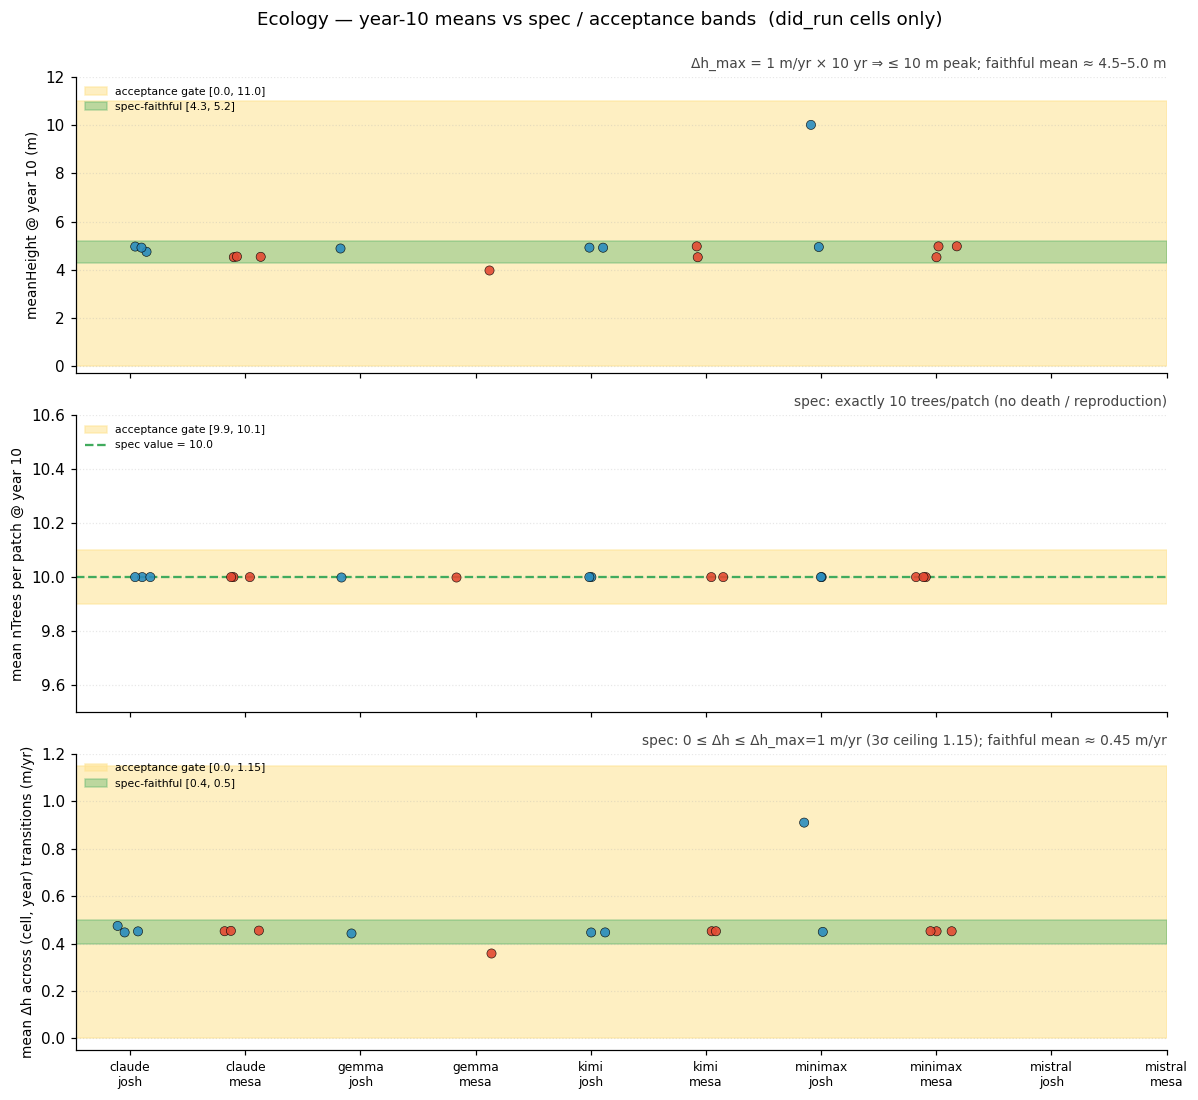

In [10]:
# Spec values pulled directly from prompts/BASE_PROMPT.md.
# Acceptance band lo/hi from harness/acceptance_ranges.json (the *gate*).
# Spec-faithful band is the *expected* value under a correct implementation
# against the phase-5a synthetic-climate dataset (EXPERIMENTAL_DESIGN.md
# §External climate inputs — gradient calibrated for ~10 m peak at the
# centre, ~0 m at the cold/dry corner, ~5 m mean across cells).
SPEC = {
    'dh_max': 1.0,                          # m / yr (BASE_PROMPT §Growth Model)
    'noise_sigma_on_O': 0.05,               # O ~ N(1, 0.05); 3σ ceiling = 1.15
    'dh_above_ceiling': 1.0 * (1 + 3 * 0.05),
    'n_trees_per_patch': 10.0,              # constant; trees don't die/move/reproduce
    'height_year10_accept': (0.0, 11.0),    # acceptance_ranges.json — known loose
    'occupancy_year10_accept': (9.9, 10.1),
    'height_year10_faithful': (4.3, 5.2),   # synthetic dataset spec-faithful band
    'growth_rate_faithful': (0.40, 0.50),   # observed mean-Δh for spec-faithful runs
}

ECO_FIELDS = [
    {
        'col':       'height_year10_mean',
        'ylabel':    'meanHeight @ year 10 (m)',
        'accept':    SPEC['height_year10_accept'],
        'faithful':  SPEC['height_year10_faithful'],
        'ylim':      (-0.3, 12.0),
        'title':     'Δh_max = 1 m/yr × 10 yr ⇒ ≤ 10 m peak; faithful mean ≈ 4.5–5.0 m',
    },
    {
        'col':       'occupancy_year10_mean',
        'ylabel':    'mean nTrees per patch @ year 10',
        'accept':    SPEC['occupancy_year10_accept'],
        'faithful':  (10.0, 10.0),
        'ylim':      (9.5, 10.6),
        'title':     'spec: exactly 10 trees/patch (no death / reproduction)',
    },
    {
        'col':       'growth_rate_mean_m',
        'ylabel':    'mean Δh across (cell, year) transitions (m/yr)',
        'accept':    (0.0, SPEC['dh_above_ceiling']),   # consistency-block ceiling
        'faithful':  SPEC['growth_rate_faithful'],
        'ylim':      (-0.05, 1.20),
        'title':     'spec: 0 ≤ Δh ≤ Δh_max=1 m/yr (3σ ceiling 1.15); faithful mean ≈ 0.45 m/yr',
    },
]


def panel_ecology(df_in: pd.DataFrame, axes: np.ndarray) -> None:
    df_eco = df_in[df_in['did_run'] == True].copy()  # noqa: E712 — pandas bool
    df_eco['xkey'] = df_eco['model'] + '\n' + df_eco['target']
    groups = [f'{m}\n{t}' for m in MODEL_ORDER for t in TARGET_ORDER]
    x_index = {g: i for i, g in enumerate(groups)}
    rng = np.random.default_rng(seed=7)

    for ax, spec in zip(axes, ECO_FIELDS):
        accept = spec['accept']
        faithful = spec['faithful']
        # Loose acceptance band (the harness gate) in pale yellow ...
        ax.axhspan(accept[0], accept[1], color='#fee391', alpha=0.55,
                   label=f'acceptance gate [{accept[0]}, {accept[1]}]')
        # ... tight spec-faithful band in green.
        if faithful[0] != faithful[1]:
            ax.axhspan(faithful[0], faithful[1], color='#41ab5d', alpha=0.35,
                       label=f'spec-faithful [{faithful[0]}, {faithful[1]}]')
        else:
            ax.axhline(faithful[0], color='#41ab5d', linewidth=1.5,
                       linestyle='--', label=f'spec value = {faithful[0]}')

        for g in groups:
            sub = df_eco[df_eco['xkey'] == g]
            if sub.empty:
                continue
            xs = x_index[g] + rng.uniform(-0.18, 0.18, size=len(sub))
            cs = [TARGET_COLORS[t] for t in sub['target']]
            ax.scatter(xs, sub[spec['col']].astype(float), c=cs, s=36,
                       alpha=0.9, edgecolor='black', linewidth=0.4, zorder=3)

        ax.set_xticks(range(len(groups)))
        ax.set_xticklabels(groups, fontsize=7)
        ax.set_ylabel(spec['ylabel'], fontsize=9)
        ax.set_ylim(*spec['ylim'])
        ax.set_title(spec['title'], fontsize=9, loc='right', color='#444')
        ax.grid(axis='y', alpha=0.3, linestyle=':')
        ax.legend(loc='upper left', fontsize=7, frameon=False)


fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
panel_ecology(df, axes)
axes[-1].tick_params(axis='x', labelsize=8)
fig.suptitle('Ecology — year-10 means vs spec / acceptance bands  (did_run cells only)',
             y=0.995, fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / 'ecology.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'ecology.png', bbox_inches='tight')
plt.show()


## Code panel — LOC, imports, comments, token entropy

EXPERIMENTAL_DESIGN.md predicts that Josh implementations should be *more
concise* than Mesa ones — the DSL has fewer free decisions, fewer scaffolding
files, and a more direct spec-to-executable mapping. Four metrics from
SCORING.md make this visible per cell:

- **`src_loc`** — lines of generated source. `.jshd` binary preprocessed
  data is excluded ([harness/_files.py](../harness/_files.py)).
- **`comment_loc`** — lines that are pure comments. The master prompt
  asks for "self-documenting, wherever possible, with comments minimized"
  (BASE_PROMPT.md §Style), so this also doubles as a prompt-adherence
  signal.
- **`imports_loc`** — `import` statements only. Mesa needs a much wider
  imports surface than Josh (a `.josh` file declares its modules
  natively).
- **`entropy_bits`** — token-level Shannon entropy of the generated code
  via tiktoken's `cl100k_base`. Higher = more varied vocabulary; very low
  values often indicate boilerplate-heavy or near-empty files.

Marker shape encodes `did_run` (filled circle = ran cleanly; open triangle
= failed). A cell at `src_loc=0` with an open triangle is "agent never
engaged at all" (mistral on this batch).


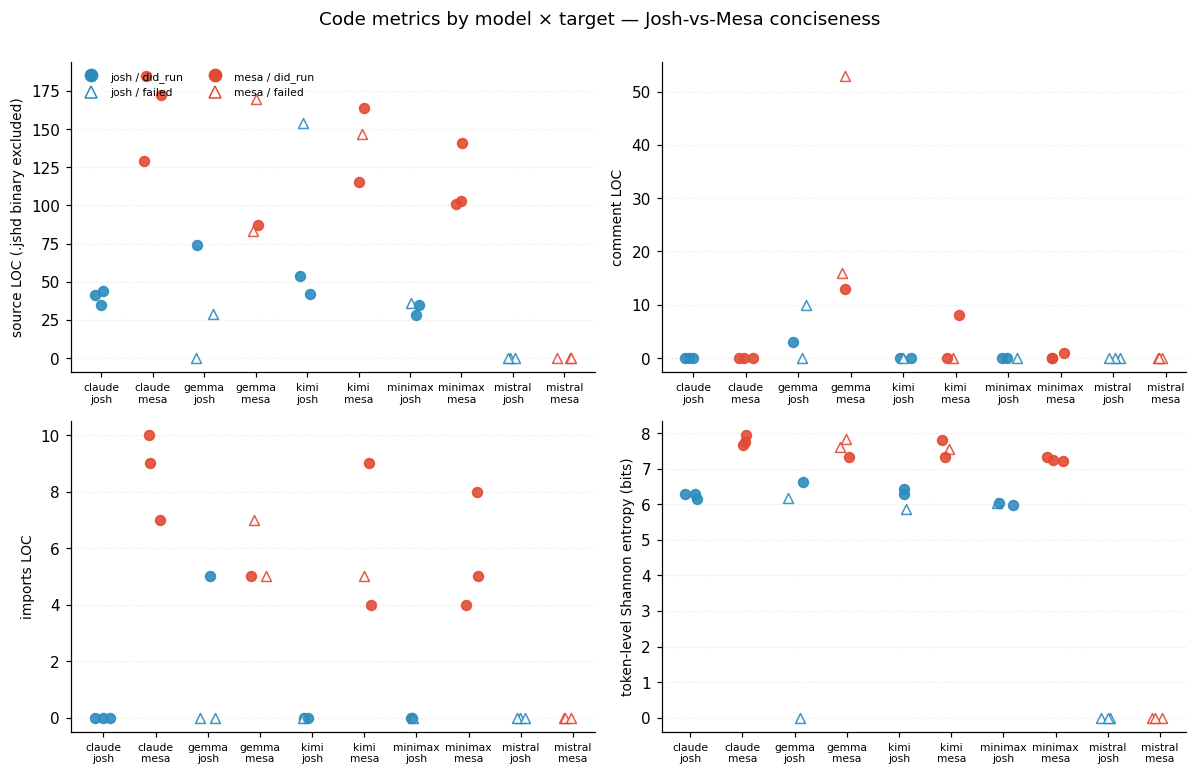

n  src_loc_median  src_loc_max  comment_loc_median  \
model   target                                                       
claude  josh    3            41.0           44                 0.0   
        mesa    3           172.0          185                 0.0   
gemma   josh    3            29.0           74                 3.0   
        mesa    3            87.0          170                16.0   
kimi    josh    3            54.0          154                 0.0   
        mesa    3           147.0          164                 0.0   
minimax josh    3            35.0           36                 0.0   
        mesa    3           103.0          141                 0.0   
mistral josh    3             0.0            0                 0.0   
        mesa    3             0.0            0                 0.0   

                imports_loc_median  entropy_bits_median  
model   target                                           
claude  josh                   0.0                 6.28  
        mesa                   9.0                 7.75  
gemma   josh                   0.0                 6.19  
        mesa                   5.0                 7.60  
kimi    josh                   0.0                 6.30  
        mesa                   5.0                 7.57  
minimax josh                   0.0                 6.03  
        mesa                   5.0                 7.25  
mistral josh                   0.0                 0.00  
        mesa                   0.0                 0.00

In [11]:
CODE_FIELDS = [
    ('src_loc',      'source LOC (.jshd binary excluded)', None),
    ('comment_loc',  'comment LOC',                         None),
    ('imports_loc',  'imports LOC',                         None),
    ('entropy_bits', 'token-level Shannon entropy (bits)',  None),
]


def panel_code(df_in: pd.DataFrame, axes: np.ndarray) -> None:
    """Code-size + entropy metrics by model × target.

    Cells with src_loc == 0 are kept (they encode "agent never engaged" —
    important signal for mistral here). did_run is overlaid as marker shape:
    filled circle = did_run, open triangle = no.
    """
    df_code = df_in.copy()
    df_code['xkey'] = df_code['model'] + '\n' + df_code['target']
    groups = [f'{m}\n{t}' for m in MODEL_ORDER for t in TARGET_ORDER]
    x_index = {g: i for i, g in enumerate(groups)}
    rng = np.random.default_rng(seed=11)

    for ax, (field, ylabel, _) in zip(axes.flat, CODE_FIELDS):
        for g in groups:
            sub = df_code[df_code['xkey'] == g]
            if sub.empty:
                continue
            xs = x_index[g] + rng.uniform(-0.18, 0.18, size=len(sub))
            for x, val, ran, tgt in zip(xs, sub[field].astype(float),
                                         sub['did_run'], sub['target']):
                marker = 'o' if bool(ran) else '^'
                facecolor = TARGET_COLORS[tgt] if bool(ran) else 'white'
                ax.scatter([x], [val], marker=marker, c=[facecolor],
                           s=42, alpha=0.9,
                           edgecolor=TARGET_COLORS[tgt], linewidth=1.0)
        ax.set_xticks(range(len(groups)))
        ax.set_xticklabels(groups, fontsize=7)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle=':')

    # Legend: marker shape encodes did_run; colour encodes target.
    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=TARGET_COLORS['josh'],
               markeredgecolor=TARGET_COLORS['josh'], markersize=8,
               label='josh / did_run'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='white',
               markeredgecolor=TARGET_COLORS['josh'], markersize=8,
               label='josh / failed'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=TARGET_COLORS['mesa'],
               markeredgecolor=TARGET_COLORS['mesa'], markersize=8,
               label='mesa / did_run'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='white',
               markeredgecolor=TARGET_COLORS['mesa'], markersize=8,
               label='mesa / failed'),
    ]
    axes.flat[0].legend(handles=legend_handles, loc='upper left',
                        fontsize=7, frameon=False, ncols=2)


fig, axes = plt.subplots(2, 2, figsize=(11, 7))
panel_code(df, axes)
fig.suptitle('Code metrics by model × target — Josh-vs-Mesa conciseness',
             y=1.00, fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / 'code.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'code.png', bbox_inches='tight')
plt.show()

# Companion table — medians + N so the figure has a number to point at.
loc_tbl = (df.groupby(['model', 'target'])
             .agg(n=('src_loc', 'size'),
                  src_loc_median=('src_loc', 'median'),
                  src_loc_max=('src_loc', 'max'),
                  comment_loc_median=('comment_loc', 'median'),
                  imports_loc_median=('imports_loc', 'median'),
                  entropy_bits_median=('entropy_bits', 'median'))
             .reindex(index=pd.MultiIndex.from_product([MODEL_ORDER, TARGET_ORDER],
                                                       names=['model', 'target']),
                      fill_value=0))
loc_tbl.round(2)


## Cost & wall time — simulation vs full agent loop

Two distinct wall-clock measurements live in the per-cell artefacts; both
are now in [aggregated.csv](aggregated.csv):

| Column | What it measures | Source |
|---|---|---|
| `sim_wall_seconds` | Just the `./run.sh` invocation inside the scorer container (`--network=none`, no LLM). **The right metric for Josh-vs-Mesa simulation cost.** | `scorer.json wall_time_seconds` ([harness/runner.py:53,76](../harness/runner.py#L53-L76)) |
| `agent_wall_seconds` | `started_at` → `ended_at` of the agent phase. Includes Docker boot + all 8 opencode invocations + LLM inference + tool execution + idle. | `time_breakdown.json wall_time_seconds` (computed from run_meta files) |

The agent-phase cost / token / tool-call totals are **summed across all
8 per-step session exports** under `agent_artifacts/steps/step_NN/session_export.json`.
The cell-level `agent_artifacts/session_export.json` is the final step
only and under-counts whole-cell totals by ~6× — see the docstring of
[orchestration/extract_time_breakdown.py](../orchestration/extract_time_breakdown.py).

What to read from the four sub-panels:

- **sim_wall** — interpretable as "how expensive is *running* the
  agent's code". For our H1 (Josh vs Mesa), this is the headline cost
  comparison: how do the two ecosystems compare in their actual runtime
  cost once an agent has produced a faithful implementation?
- **agent_wall** — interpretable as "how much agent activity did this
  cell consume". Two-to-three orders of magnitude larger than sim_wall.
  Mistral cells sit at ~12s of agent_wall — the model returned
  immediately without engaging the multi-invocation flow.
- **agent_cost_usd** — dollar cost from the per-step OpenRouter
  responses. Note the wide spread across models (claude opus is ~50× the
  cost of gemma per cell), and within-model spread by target.
- **agent_tool_calls** — total tool invocations across all 8 steps.
  A direct activity signal; pairs with `agent_cost_usd` to identify
  "active but cheap" (lots of small calls) vs "few but expensive"
  (long-context reasoning) cells.

Marker shape encodes `did_run` (filled = ran cleanly; open triangle = failed).


In [ ]:
COST_FIELDS = [
    ('sim_wall_seconds',     'sim wall time (s) — pure ./run.sh',     'linear'),
    ('agent_wall_seconds',   'agent wall time (s) — full cell',       'linear'),
    ('agent_cost_usd',       'agent cost (USD) — sum across 8 steps', 'linear'),
    ('agent_tool_calls',     'agent tool calls — sum across 8 steps', 'linear'),
]


def panel_cost(df_in: pd.DataFrame, axes: np.ndarray) -> None:
    """Side-by-side: simulation wall, agent wall, cost, tool-call count.

    Marker shape encodes did_run (filled circle = ran, triangle = failed).
    Cells with sim_wall=0 (e.g. mistral — no run.sh produced) are kept
    so the "agent never engaged" signal stays visible.
    """
    df_c = df_in.copy()
    df_c['xkey'] = df_c['model'] + '\n' + df_c['target']
    groups = [f'{m}\n{t}' for m in MODEL_ORDER for t in TARGET_ORDER]
    x_index = {g: i for i, g in enumerate(groups)}
    rng = np.random.default_rng(seed=23)

    for ax, (field, ylabel, scale) in zip(axes.flat, COST_FIELDS):
        for g in groups:
            sub = df_c[df_c['xkey'] == g]
            if sub.empty:
                continue
            xs = x_index[g] + rng.uniform(-0.18, 0.18, size=len(sub))
            for x, val, ran, tgt in zip(xs, sub[field].astype(float),
                                         sub['did_run'], sub['target']):
                marker = 'o' if bool(ran) else '^'
                facecolor = TARGET_COLORS[tgt] if bool(ran) else 'white'
                ax.scatter([x], [val], marker=marker, c=[facecolor],
                           s=42, alpha=0.9,
                           edgecolor=TARGET_COLORS[tgt], linewidth=1.0)
        ax.set_xticks(range(len(groups)))
        ax.set_xticklabels(groups, fontsize=7)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_yscale(scale)
        ax.grid(axis='y', alpha=0.3, linestyle=':')


fig, axes = plt.subplots(2, 2, figsize=(11, 7))
panel_cost(df, axes)
fig.suptitle('Cost & wall time — sim execution vs full agent loop',
             y=1.00, fontsize=12)
fig.tight_layout()
fig.savefig(OUT_DIR / 'cost_walltime.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'cost_walltime.png', bbox_inches='tight')
plt.show()

# Companion table — what's the per-cell budget look like, per model x target?
cost_tbl = (df.groupby(['model', 'target'])
              .agg(n=('did_run', 'size'),
                   ran=('did_run', 'sum'),
                   sim_wall_med=('sim_wall_seconds', 'median'),
                   agent_wall_min=('agent_wall_seconds',
                                    lambda s: round(s.mean() / 60, 1)),
                   cost_usd_mean=('agent_cost_usd', 'mean'),
                   cost_usd_max=('agent_cost_usd', 'max'),
                   tool_calls_mean=('agent_tool_calls', 'mean'),
                   in_tokens_k=('agent_tokens_input',
                                 lambda s: round(s.mean() / 1000, 1)),
                   cache_read_M=('agent_tokens_cache_read',
                                  lambda s: round(s.mean() / 1_000_000, 2)))
              .reindex(index=pd.MultiIndex.from_product(
                          [MODEL_ORDER, TARGET_ORDER], names=['model', 'target']),
                       fill_value=0))
print('=== Per-(model, target) cost & timing summary ===')
print(cost_tbl.round(2).to_string())
print()
print(f"BATCH TOTAL: ${df['agent_cost_usd'].sum():.2f} | "
      f"{df['agent_wall_seconds'].sum() / 3600:.1f} agent-hours | "
      f"{df['sim_wall_seconds'].sum():.0f} sim-seconds | "
      f"{int(df['agent_tool_calls'].sum())} tool calls")


## Fuzzy-judge responses — Q1 (right tool?) + Q2 (where did the agent get confused?)

The post-hoc LLM-judge (SCORING.md §LLM-judge passes) answers two free-text
questions per cell against the agent's `workspace/` plus the rendered
transcript. We surface them here as a clustering aid for failure modes the
mechanical scorer cannot describe in words.

- **Q1** — `yes` / `partial` / `no` plus a one-sentence justification. Mostly
  corroborates `target_conformance`; the partial/no cases are the interesting
  ones (e.g. agent imported the framework but did the real work in plain
  numpy — the exact loophole SCORING.md §1 calls out).
- **Q2** — 1–3 specific steps, files, or errors where the agent got stuck.
  Useful for cross-cell pattern-spotting (e.g. "every kimi-josh cell tripped
  on `.jshd` preprocessing", or "every mistral cell exited immediately
  without invoking any tool").

Header columns recap mechanical state next to the judge text so the two
can be read together.


In [12]:
import textwrap

Q1_GLYPH = {'yes': '✓', 'no': '✗', 'partial': '~'}


def fuzzy_q1_pivot(df_in: pd.DataFrame) -> pd.DataFrame:
    p = (df_in.assign(present=1)
              .pivot_table(index=['model', 'target'],
                           columns='fuzzy_q1_answer',
                           values='present',
                           aggfunc='sum',
                           fill_value=0))
    for col in ('yes', 'partial', 'no'):
        if col not in p.columns:
            p[col] = 0
    p = p[['yes', 'partial', 'no']]
    p['glyphs'] = p.apply(
        lambda r: '✓' * int(r['yes']) + '~' * int(r['partial']) + '✗' * int(r['no']),
        axis=1)
    return p.reindex(
        index=pd.MultiIndex.from_product([MODEL_ORDER, TARGET_ORDER],
                                          names=['model', 'target']),
        fill_value=0)


q1 = fuzzy_q1_pivot(df)
print('=== Q1: "Did the agent use the named framework?" ===')
print(q1)
print()


def _fmt(value, spec='', na='NA'):
    if pd.isna(value):
        return na
    return format(value, spec) if spec else str(value)


def _wrap(text: object, width: int = 100, indent: str = '      ') -> str:
    if not isinstance(text, str) or not text.strip():
        return '(none)'
    return ('\n' + indent).join(textwrap.wrap(text.strip(), width=width)) or '(none)'


print('=== Per-cell judge text (sorted by model, target, fuzzy answer) ===\n')
ordered = df.assign(
    _m=df['model'].map({m: i for i, m in enumerate(MODEL_ORDER)}),
    _t=df['target'].map({t: i for i, t in enumerate(TARGET_ORDER)}),
    _a=df['fuzzy_q1_answer'].map({'yes': 0, 'partial': 1, 'no': 2}).fillna(3),
).sort_values(['_m', '_t', '_a', 'run_id'])

for _, row in ordered.iterrows():
    glyph = Q1_GLYPH.get(row.get('fuzzy_q1_answer'), '?')
    header = (
        f"[{glyph}] {row['model']:<7s} {row['target']:<4s}  "
        f"did_run={'Y' if row['did_run'] else 'N'}  "
        f"conform={'Y' if row['target_conformance'] else 'N'}  "
        f"h10={_fmt(row['height_year10_mean'], '.2f')}m  "
        f"src_loc={_fmt(row['src_loc'], '.0f')}  "
        f"todos={_fmt(row['plan_todos_checked'], '.0f')}/8"
    )
    print(header)
    print(f"   Q1: {_wrap(row['fuzzy_q1_justification'])}")
    print(f"   Q2: {_wrap(row['fuzzy_q2_observations'])}")
    print()


=== Q1: "Did the agent use the named framework?" ===
fuzzy_q1_answer  yes  partial  no glyphs
model   target                          
claude  josh       3        0   0    ✓✓✓
        mesa       3        0   0    ✓✓✓
gemma   josh       1        1   1    ✓~✗
        mesa       3        0   0    ✓✓✓
kimi    josh       2        0   0     ✓✓
        mesa       3        0   0    ✓✓✓
minimax josh       3        0   0    ✓✓✓
        mesa       3        0   0    ✓✓✓
mistral josh       0        0   3    ✗✗✗
        mesa       0        0   3    ✗✗✗

=== Per-cell judge text (sorted by model, target, fuzzy answer) ===

[✓] claude  josh  did_run=Y  conform=Y  h10=4.92m  src_loc=44  todos=8/8
   Q1: The ecological model is implemented entirely in `simulation.josh`, using Josh patch and organism
      constructs, external climate inputs, and Josh exports for all simulation logic.
   Q2: This invocation only removed duplicate unit declarations and reran `./run.sh`; there were no
      tangents or repe

### Appendix: per-(model, target) summary table

Companion to the figure for the paper text — k/N and proportion at each gate level.


In [13]:
tbl = (df.groupby(['model', 'target'])
         .agg(n=('did_run', 'size'),
              did_run=('did_run', 'sum'),
              conformed=('target_conformance', 'sum'),
              in_range=('height_in_range', 'sum'))
         .reindex(index=pd.MultiIndex.from_product([MODEL_ORDER, TARGET_ORDER],
                                                    names=['model', 'target']),
                  fill_value=0))
tbl['did_run_rate'] = (tbl['did_run'] / tbl['n']).round(2)
tbl['conform_rate'] = (tbl['conformed'] / tbl['n']).round(2)
tbl


n  did_run  conformed  in_range  did_run_rate  conform_rate
model   target                                                             
claude  josh    3        3          3         3          1.00          1.00
        mesa    3        3          3         3          1.00          1.00
gemma   josh    3        1          0         1          0.33          0.00
        mesa    3        1          3         2          0.33          1.00
kimi    josh    3        2          2         2          0.67          0.67
        mesa    3        2          3         2          0.67          1.00
minimax josh    3        2          3         2          0.67          1.00
        mesa    3        3          3         3          1.00          1.00
mistral josh    3        0          0         0          0.00          0.00
        mesa    3        0          0         0          0.00          0.00